In [1]:
"""Cell 0: Imports and constants — run this first after any kernel restart"""

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paths ─────────────────────────────────────────────────────────────────
CAMELS_DIR = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001'
SHP_PATH   = f'{CAMELS_DIR}/polygon/polygon.shp'
Q_PATH     = f'{CAMELS_DIR}/q_m3s_mon.csv'
NC_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET/WA1/run_output_2000_2019_hydro_TC_WA1.nc'
RGI_PATH   = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

# ── Constants ─────────────────────────────────────────────────────────────
ICE_DENSITY   = 900     # kg/m³
WATER_DENSITY = 1000    # kg/m³

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Plot colors ───────────────────────────────────────────────────────────
C_Q     = '#2196F3'
C_IMBAL = '#FF5722'
C_MELT  = '#9C27B0'
C_FR    = '#4CAF50'

print('✓ Cell 0 complete — imports, paths, constants loaded')
print(f'  NC_PATH:  {NC_PATH}')
print(f'  Q_PATH:   {Q_PATH}')
print(f'  SHP_PATH: {SHP_PATH}')

✓ Cell 0 complete — imports, paths, constants loaded
  NC_PATH:  /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET/WA1/run_output_2000_2019_hydro_TC_WA1.nc
  Q_PATH:   /Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001/q_m3s_mon.csv
  SHP_PATH: /Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001/polygon/polygon.shp


In [2]:
"""Cell 1: Spatial join — find RGI glaciers inside Allipen basin"""

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

# ── Paths ─────────────────────────────────────────────────────────────────
CAMELS_DIR = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/CAMELS/camels_cl_9402001'
SHP_PATH   = f'{CAMELS_DIR}/polygon/polygon.shp'
Q_PATH     = f'{CAMELS_DIR}/q_m3s_mon.csv'
NC_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/CR2MET/WA1/run_output_2000_2019_hydro_TC_WA1.nc'
RGI_PATH   = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

ICE_DENSITY   = 900
WATER_DENSITY = 1000

# Load basin polygon
basin = gpd.read_file(SHP_PATH).to_crs('EPSG:4326')
basin_area_km2 = basin.to_crs('EPSG:32718').area.values[0] / 1e6
print(f'Basin area: {basin_area_km2:.1f} km²')

# Load RGI and do point-in-polygon join
rgi     = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi, geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat), crs='EPSG:4326')
glaciers_in_basin = gpd.sjoin(gdf_rgi, basin, how='inner', predicate='within')
rgi_ids = glaciers_in_basin['RGIId'].values

glacier_area = glaciers_in_basin['Area'].sum()
print(f'Glaciers in basin:  {len(rgi_ids)}')
print(f'Total glacier area: {glacier_area:.2f} km²  '
      f'({glacier_area / basin_area_km2 * 100:.1f}% of basin)')

Basin area: 830.4 km²
Glaciers in basin:  92
Total glacier area: 35.56 km²  (4.3% of basin)


In [3]:
"""Cell 2 FIXED: Extract annual volume loss — fix time coordinate parsing"""

ds   = xr.open_dataset(NC_PATH)
mask = np.isin(ds['rgi_id'].values, rgi_ids)
print(f'Matched {mask.sum()} / {len(rgi_ids)} glaciers in NetCDF')

# Diagnose the time coordinate
print(f'\nRaw time values: {ds["time"].values}')
print(f'Time dtype: {ds["time"].dtype}')
print(f'Time attrs: {ds["time"].attrs}')

# OGGM stores time as integer years (e.g. 2000, 2001...) not datetime
# Extract directly as integers
time_vals = ds['time'].values
print(f'\nTime values as-is: {time_vals}')

# If they're already integers like 2000-2019, use directly
# If they decoded wrongly, cast to int
years = time_vals.astype(int)
print(f'Years: {years}')

# Annual volume summed across basin glaciers
vol        = ds['volume'].sel(rgi_id=ds['rgi_id'][mask]).sum(dim='rgi_id')
vol_series = pd.Series(vol.values, index=years, name='volume_m3_ice')

print(f'\nVolume series:')
print(vol_series)

# Δvolume → water (positive = ice loss released to runoff)
dvol_annual   = vol_series.diff().shift(-1)   # ← add .shift(-1)
dwater_annual = (-dvol_annual * (ICE_DENSITY / WATER_DENSITY)).clip(lower=0)
dwater_annual.name = 'glacier_water_m3'

print(f'\nMean annual ice loss → water: {dwater_annual.mean():.2e} m³/yr')
print(f'\nFull annual series:')
print(dwater_annual.dropna().to_string())

Matched 92 / 92 glaciers in NetCDF

Raw time values: [1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007. 2008. 2009. 2010.
 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022.]
Time dtype: float64
Time attrs: {'description': 'Floating hydrological year'}

Time values as-is: [1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007. 2008. 2009. 2010.
 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022.]
Years: [1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]

Volume series:
1999    2.509964e+09
2000    2.479768e+09
2001    2.489191e+09
2002    2.471003e+09
2003    2.463325e+09
2004    2.439903e+09
2005    2.402524e+09
2006    2.418851e+09
2007    2.415346e+09
2008    2.377977e+09
2009    2.331064e+09
2010    2.313969e+09
2011    2.283623e+09
2012    2.240386e+09
2013    2.185672e+09
2014    2.137098e+09
2015    2.115194e+09
2016    2.089262e+09
2017    2.009015e+09
2018    1.

In [4]:
"""Cell 3: Extract total ablation flux (melt_on_glacier_monthly)
   Units: kg → m³ water (divide by water density)
   Note: this is the total ablation flux, NOT net volume change.
   melt_on_glacier >> Δvolume because accumulation replenishes much of
   what melts — the glacier storage barely changes even though significant
   melt water flows through it seasonally.
"""

melt_2d = ds['melt_on_glacier_monthly'].sel(
    rgi_id=ds['rgi_id'][mask]).sum(dim='rgi_id')  # shape: (24 years, 12 months)

# Build (years × 12) DataFrame then stack to monthly series
melt_df = pd.DataFrame(melt_2d.values, index=years, columns=range(1, 13))
melt_monthly = melt_df.stack()
melt_monthly.index = pd.to_datetime(
    [f'{y}-{m:02d}-01' for y, m in melt_monthly.index])
melt_monthly = melt_monthly.sort_index()

# Convert kg → m³ water
melt_monthly = melt_monthly / WATER_DENSITY
melt_monthly.name = 'melt_on_glacier_m3'

# Annual sum
melt_annual = melt_monthly.resample('YE').sum()
melt_annual.index = melt_annual.index.year

print('Sanity check:')
print(f'  Mean annual ablation flux (m³/yr):  {melt_annual.mean():.2e}  ← total melt')
print(f'  Mean annual Δvolume→water (m³/yr):  {dwater_annual.mean():.2e}  ← net ice loss')
print(f'  Ablation / Δvolume ratio:           {melt_annual.mean() / dwater_annual.mean():.1f}x')
print(f'  → accumulation offsets ~{(1 - dwater_annual.mean()/melt_annual.mean())*100:.0f}% of annual melt in this basin')
print(f'\n✓ Run Cell 4 next, then Cell 5 for fractions vs Q')

Sanity check:
  Mean annual ablation flux (m³/yr):  9.31e+07  ← total melt
  Mean annual Δvolume→water (m³/yr):  2.98e+07  ← net ice loss
  Ablation / Δvolume ratio:           3.1x
  → accumulation offsets ~68% of annual melt in this basin

✓ Run Cell 4 next, then Cell 5 for fractions vs Q


In [5]:
"""Cell 4: Load CAMELS Q, convert m³/s → m³/month and m³/yr"""

q_raw = pd.read_csv(Q_PATH)
q_raw['date'] = pd.to_datetime(q_raw['date'])
q_raw = q_raw.set_index('date')
q_m3s = q_raw['9402001']

# m³/s → m³/month
q_m3_month = (q_m3s * q_m3s.index.days_in_month * 86400).dropna()

# Annual totals
q_annual = q_m3_month.resample('YE').sum()
q_annual.index = q_annual.index.year

print(f'Q period: {q_m3_month.index.min().date()} to {q_m3_month.index.max().date()}')
print(f'Mean annual Q: {q_annual.mean():.2e} m³/yr')
print(f'\nAnnual Q series:')
print(q_annual.to_string())

Q period: 1985-01-01 to 2019-02-01
Mean annual Q: 2.04e+09 m³/yr

Annual Q series:
date
1985    2.417108e+09
1986    2.599969e+09
1987    2.113021e+09
1988    1.778724e+09
1989    1.818091e+09
1990    2.455177e+09
1991    2.202663e+09
1992    2.471404e+09
1993    3.339808e+09
1994    2.862193e+09
1995    2.798149e+09
1996    1.801950e+09
1997    2.430192e+09
1998    1.445100e+09
1999    1.569100e+09
2000    2.189172e+09
2001    2.600601e+09
2002    2.526361e+09
2003    2.309311e+09
2004    2.331715e+09
2005    2.576785e+09
2006    1.339170e+09
2007    1.755488e+09
2008    2.274393e+09
2009    2.594065e+09
2010    1.932690e+09
2011    1.985135e+09
2012    1.933805e+09
2013    1.771271e+09
2014    2.004269e+09
2015    1.548720e+09
2016    9.194605e+08
2017    4.475956e+08
2018    2.086493e+09
2019    2.845398e+08


In [6]:
"""Cell 5: Align timeseries and compute glacier contribution (annual + monthly)
   Two metrics reported:
   - Ablation contribution:    total melt flux / Q  (~7% — includes melt replenished by accumulation)
   - Imbalance contribution:   net ice loss (Δvolume → water) / Q  (~2.5% — non-renewable, unsustainable)
   The difference between the two is melt that is recycled — melted in summer, replenished by winter snowfall.
"""

# ── Annual ────────────────────────────────────────────────────────────────
common_years = (dwater_annual.dropna().index.intersection(q_annual.index))
common_years = common_years[(common_years >= 2000) & (common_years <= 2019)]

q_ann      = q_annual.loc[common_years]
gl_imbal   = dwater_annual.loc[common_years]    # net ice loss → water
gl_melt    = melt_annual.loc[common_years]      # total ablation flux → water

frac_imbal = (gl_imbal / q_ann * 100).clip(0, 100)
frac_melt  = (gl_melt  / q_ann * 100).clip(0, 100)

print(f'Common years: {common_years[0]}–{common_years[-1]}')
print(f'\nMean annual Q:                         {q_ann.mean():.2e} m³/yr')
print(f'\nAblation contribution (total melt):')
print(f'  Mean: {frac_melt.mean():.1f}%   Max: {frac_melt.max():.1f}% (year {frac_melt.idxmax()})')
print(f'\nImbalance contribution (net ice loss):')
print(f'  Mean: {frac_imbal.mean():.1f}%   Max: {frac_imbal.max():.1f}% (year {frac_imbal.idxmax()})')

# ── Monthly ───────────────────────────────────────────────────────────────
start, end = f'{common_years[0]}-01-01', f'{common_years[-1]}-12-31'
q_mon      = q_m3_month.loc[start:end]
gl_mon     = melt_monthly.loc[start:end]
common_mon = q_mon.index.intersection(gl_mon.index)
q_mon_c    = q_mon.loc[common_mon]
gl_mon_c   = gl_mon.loc[common_mon]

frac_melt_mon = (gl_mon_c / q_mon_c * 100).clip(0, 100)

# Seasonal means
gl_seasonal  = frac_melt_mon.groupby(frac_melt_mon.index.month).mean()
q_seasonal   = q_mon_c.groupby(q_mon_c.index.month).mean()
gl_mon_mean  = gl_mon_c.groupby(gl_mon_c.index.month).mean()

print(f'\nMonthly ablation contribution:')
print(f'  Mean: {frac_melt_mon.mean():.1f}%')
print(f'  Peak month: {MONTH_NAMES[gl_seasonal.idxmax()-1]} ({gl_seasonal.max():.1f}%)')

Common years: 2000–2019

Mean annual Q:                         1.87e+09 m³/yr

Ablation contribution (total melt):
  Mean: 7.3%   Max: 33.2% (year 2019)

Imbalance contribution (net ice loss):
  Mean: 2.3%   Max: 11.5% (year 2019)

Monthly ablation contribution:
  Mean: 5.9%
  Peak month: Feb (17.8%)


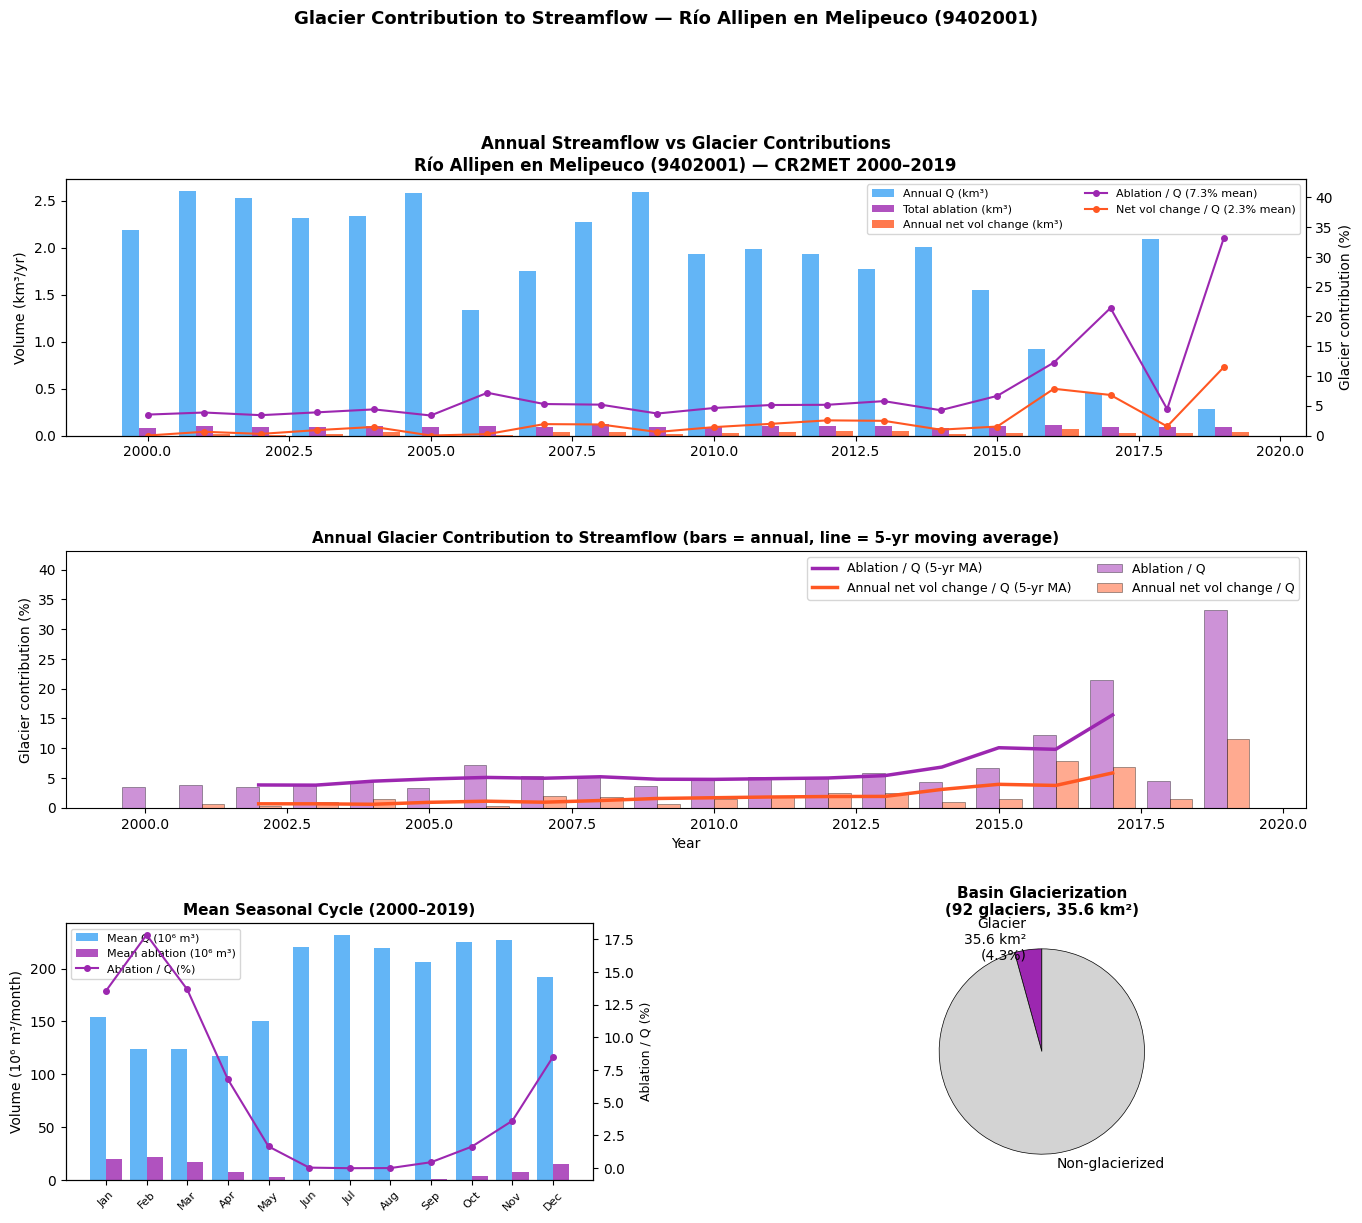

In [7]:
"""Cell 6: Plot annual + seasonal glacier contributions"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

C_Q      = '#2196F3'
C_IMBAL  = '#FF5722'   # net volume change
C_MELT   = '#9C27B0'   # total ablation
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Annual Q vs both glacier quantities ───────────────────────────
ax1  = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()

x = np.array(common_years, dtype=float)
ax1.bar(x - 0.3, q_ann    / 1e9, width=0.3, color=C_Q,     alpha=0.7, label='Annual Q (km³)')
ax1.bar(x,       gl_melt  / 1e9, width=0.3, color=C_MELT,  alpha=0.8, label='Total ablation (km³)')
ax1.bar(x + 0.3, gl_imbal / 1e9, width=0.3, color=C_IMBAL, alpha=0.8, label='Annual net vol change (km³)')
ax1b.plot(x, frac_melt.values,  '-o', color=C_MELT,  markersize=4, linewidth=1.5,
          label=f'Ablation / Q ({frac_melt.mean():.1f}% mean)')
ax1b.plot(x, frac_imbal.values, '-o', color=C_IMBAL, markersize=4, linewidth=1.5,
          label=f'Net vol change / Q ({frac_imbal.mean():.1f}% mean)')

ax1.set_ylabel('Volume (km³/yr)', fontsize=10)
ax1b.set_ylabel('Glacier contribution (%)', fontsize=10)
ax1b.set_ylim(0, max(frac_melt.max() * 1.3, 10))
ax1.set_title('Annual Streamflow vs Glacier Contributions\n'
              'Río Allipen en Melipeuco (9402001) — CR2MET 2000–2019',
              fontsize=12, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right', ncol=2)

# ── Panel 2: Annual fractions with 5-yr moving average ────────────────────
ax2 = fig.add_subplot(gs[1, :])

# Bar charts
ax2.bar(x - 0.2, frac_melt.values,  width=0.4, color=C_MELT,
        alpha=0.5, edgecolor='black', linewidth=0.5, label='Ablation / Q')
ax2.bar(x + 0.2, frac_imbal.values, width=0.4, color=C_IMBAL,
        alpha=0.5, edgecolor='black', linewidth=0.5, label='Annual net vol change / Q')

# 5-year moving averages
ma_melt  = pd.Series(frac_melt.values,  index=x).rolling(5, center=True).mean()
ma_imbal = pd.Series(frac_imbal.values, index=x).rolling(5, center=True).mean()

ax2.plot(x, ma_melt.values,  '-', color=C_MELT,  linewidth=2.5,
         label='Ablation / Q (5-yr MA)')
ax2.plot(x, ma_imbal.values, '-', color=C_IMBAL, linewidth=2.5,
         label='Annual net vol change / Q (5-yr MA)')

ax2.set_ylabel('Glacier contribution (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, max(frac_melt.max() * 1.3, 5))
ax2.set_title('Annual Glacier Contribution to Streamflow (bars = annual, line = 5-yr moving average)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, ncol=2)

# ── Panel 3: Mean seasonal cycle ──────────────────────────────────────────
ax3  = fig.add_subplot(gs[2, 0])
ax3b = ax3.twinx()
ax3.bar(np.arange(1,13) - 0.2, q_seasonal  / 1e6, width=0.4,
        color=C_Q,    alpha=0.7, label='Mean Q (10⁶ m³)')
ax3.bar(np.arange(1,13) + 0.2, gl_mon_mean / 1e6, width=0.4,
        color=C_MELT, alpha=0.8, label='Mean ablation (10⁶ m³)')
ax3b.plot(range(1,13), gl_seasonal.values, '-o',
          color=C_MELT, markersize=4, linewidth=1.5, label='Ablation / Q (%)')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(MONTH_NAMES, fontsize=8, rotation=45)
ax3.set_ylabel('Volume (10⁶ m³/month)', fontsize=10)
ax3b.set_ylabel('Ablation / Q (%)', fontsize=9)
ax3.set_title('Mean Seasonal Cycle (2000–2019)', fontsize=11, fontweight='bold')
lines3, labs3 = ax3.get_legend_handles_labels()
lines4, labs4 = ax3b.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labs3 + labs4, fontsize=8)

# ── Panel 4: Basin glacierization pie ─────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
glacier_pct = glacier_area / basin_area_km2 * 100
sizes  = [glacier_area, basin_area_km2 - glacier_area]
labels = [f'Glacier\n{glacier_area:.1f} km²\n({glacier_pct:.1f}%)', 'Non-glacierized']
ax4.pie(sizes, labels=labels, colors=[C_MELT, 'lightgray'],
        startangle=90, wedgeprops=dict(edgecolor='black', linewidth=0.5))
ax4.set_title(f'Basin Glacierization\n({len(rgi_ids)} glaciers, {glacier_area:.1f} km²)',
              fontsize=11, fontweight='bold')

plt.suptitle('Glacier Contribution to Streamflow — Río Allipen en Melipeuco (9402001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_glacier_contribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

## redoing per Ale's suggestion w fewer variables mapped: 

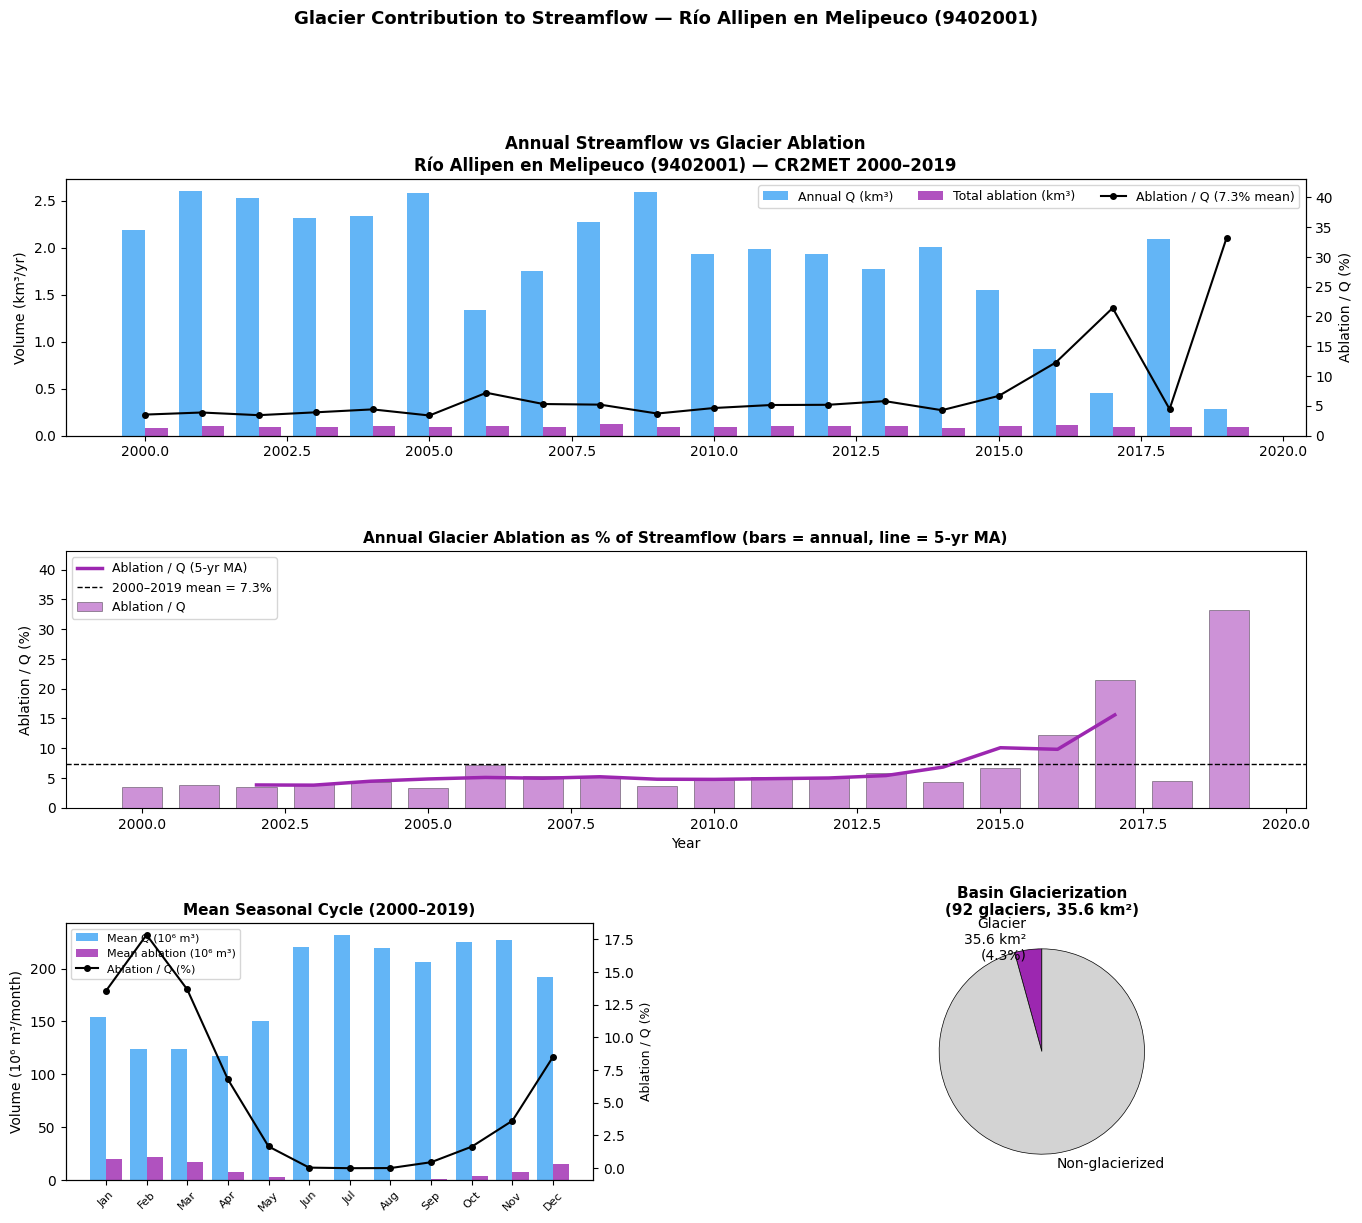

In [11]:
"""Cell 6: Plot annual + seasonal glacier contributions"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

C_Q    = '#2196F3'
C_MELT = '#9C27B0'
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Annual Q vs ablation (volumes) ───────────────────────────────
ax1  = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()

x = np.array(common_years, dtype=float)
ax1.bar(x - 0.2, q_ann   / 1e9, width=0.4, color=C_Q,    alpha=0.7, label='Annual Q (km³)')
ax1.bar(x + 0.2, gl_melt / 1e9, width=0.4, color=C_MELT, alpha=0.8, label='Total ablation (km³)')
ax1b.plot(x, frac_melt.values, '-o', color='black', markersize=4, linewidth=1.5,
          label=f'Ablation / Q ({frac_melt.mean():.1f}% mean)')

ax1.set_ylabel('Volume (km³/yr)', fontsize=10)
ax1b.set_ylabel('Ablation / Q (%)', fontsize=10)
ax1b.set_ylim(0, max(frac_melt.max() * 1.3, 10))
ax1.set_title('Annual Streamflow vs Glacier Ablation\n'
              'Río Allipen en Melipeuco (9402001) — CR2MET 2000–2019',
              fontsize=12, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right', ncol=3)

# ── Panel 2: Ablation / Q fraction with 5-yr moving average ───────────────
ax2 = fig.add_subplot(gs[1, :])

ax2.bar(x, frac_melt.values, width=0.7, color=C_MELT,
        alpha=0.5, edgecolor='black', linewidth=0.5, label='Ablation / Q')

ma_melt = pd.Series(frac_melt.values, index=x).rolling(5, center=True).mean()
ax2.plot(x, ma_melt.values, '-', color=C_MELT, linewidth=2.5,
         label='Ablation / Q (5-yr MA)')
ax2.axhline(frac_melt.mean(), color='black', linestyle='--', linewidth=1,
            label=f'2000–2019 mean = {frac_melt.mean():.1f}%')

ax2.set_ylabel('Ablation / Q (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, max(frac_melt.max() * 1.3, 5))
ax2.set_title('Annual Glacier Ablation as % of Streamflow (bars = annual, line = 5-yr MA)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

# ── Panel 3: Mean seasonal cycle ──────────────────────────────────────────
ax3  = fig.add_subplot(gs[2, 0])
ax3b = ax3.twinx()
ax3.bar(np.arange(1,13) - 0.2, q_seasonal  / 1e6, width=0.4,
        color=C_Q,    alpha=0.7, label='Mean Q (10⁶ m³)')
ax3.bar(np.arange(1,13) + 0.2, gl_mon_mean / 1e6, width=0.4,
        color=C_MELT, alpha=0.8, label='Mean ablation (10⁶ m³)')
ax3b.plot(range(1,13), gl_seasonal.values, '-o',
          color='black', markersize=4, linewidth=1.5, label='Ablation / Q (%)')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(MONTH_NAMES, fontsize=8, rotation=45)
ax3.set_ylabel('Volume (10⁶ m³/month)', fontsize=10)
ax3b.set_ylabel('Ablation / Q (%)', fontsize=9)
ax3.set_title('Mean Seasonal Cycle (2000–2019)', fontsize=11, fontweight='bold')
lines3, labs3 = ax3.get_legend_handles_labels()
lines4, labs4 = ax3b.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labs3 + labs4, fontsize=8)

# ── Panel 4: Basin glacierization pie ─────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
glacier_pct = glacier_area / basin_area_km2 * 100
sizes  = [glacier_area, basin_area_km2 - glacier_area]
labels = [f'Glacier\n{glacier_area:.1f} km²\n({glacier_pct:.1f}%)', 'Non-glacierized']
ax4.pie(sizes, labels=labels, colors=[C_MELT, 'lightgray'],
        startangle=90, wedgeprops=dict(edgecolor='black', linewidth=0.5))
ax4.set_title(f'Basin Glacierization\n({len(rgi_ids)} glaciers, {glacier_area:.1f} km²)',
              fontsize=11, fontweight='bold')

plt.suptitle('Glacier Contribution to Streamflow — Río Allipen en Melipeuco (9402001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_glacier_contribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

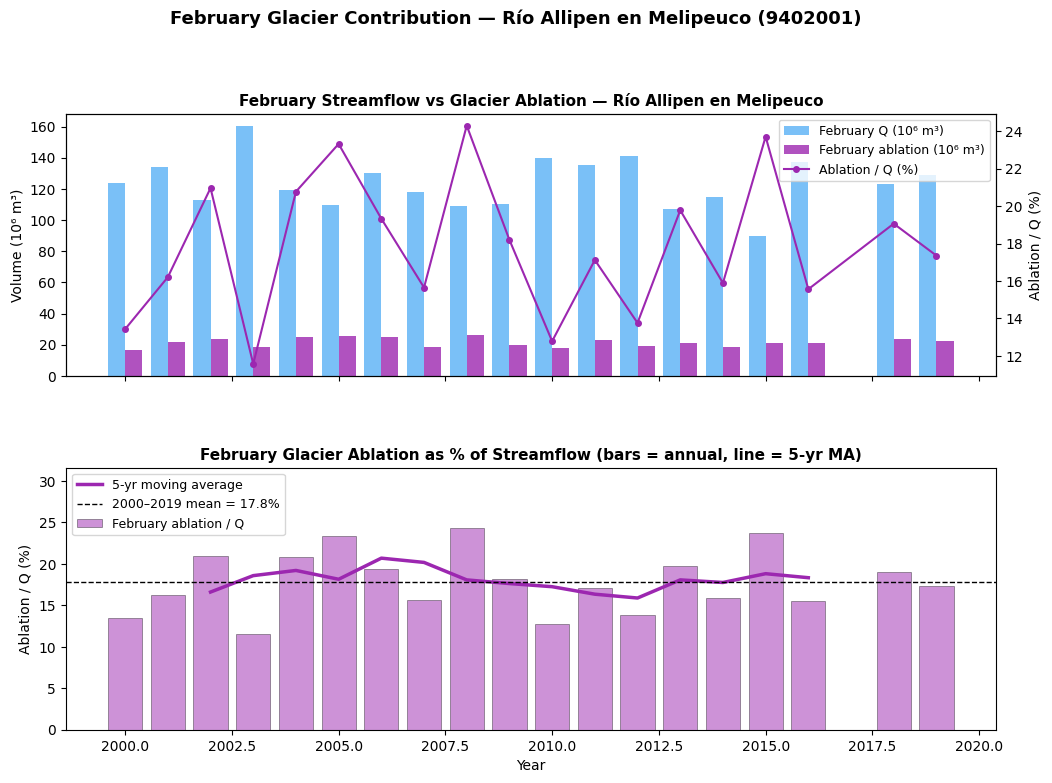


February statistics:
  Mean ablation / Q:  17.8%
  Max ablation / Q:   24.3%  (year 2008)
  Min ablation / Q:   11.6%  (year 2003)


In [8]:
"""Cell 6b: February glacier contribution timeseries (2000–2019)
   February = peak late-summer melt month in Southern Hemisphere
"""

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.subplots_adjust(hspace=0.35)

# Filter to February only
feb_mask  = frac_melt_mon.index.month == 2
feb_melt  = frac_melt_mon[feb_mask]
feb_q     = q_mon_c[feb_mask]
feb_gl    = gl_mon_c[feb_mask]
feb_years = feb_melt.index.year

# 5-yr moving average on February fraction
feb_ma = feb_melt.copy()
feb_ma.index = feb_years
feb_ma_roll = feb_ma.rolling(5, center=True).mean()

# ── Panel 1: February Q vs ablation (m³) ──────────────────────────────────
ax1  = axes[0]
ax1b = ax1.twinx()
ax1.bar(feb_years - 0.2, feb_q  / 1e6, width=0.4, color=C_Q,    alpha=0.6, label='February Q (10⁶ m³)')
ax1.bar(feb_years + 0.2, feb_gl / 1e6, width=0.4, color=C_MELT, alpha=0.8, label='February ablation (10⁶ m³)')
ax1b.plot(feb_years, feb_melt.values, '-o', color=C_MELT,
          markersize=4, linewidth=1.5, label='Ablation / Q (%)')
ax1.set_ylabel('Volume (10⁶ m³)', fontsize=10)
ax1b.set_ylabel('Ablation / Q (%)', fontsize=10)
ax1.set_title('February Streamflow vs Glacier Ablation — Río Allipen en Melipeuco',
              fontsize=11, fontweight='bold')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right')

# ── Panel 2: February ablation fraction + 5-yr MA ─────────────────────────
ax2 = axes[1]
ax2.bar(feb_years, feb_melt.values, color=C_MELT, alpha=0.5,
        edgecolor='black', linewidth=0.5, label='February ablation / Q')
ax2.plot(feb_years, feb_ma_roll.values, '-', color=C_MELT,
         linewidth=2.5, label='5-yr moving average')
ax2.axhline(feb_melt.mean(), color='black', linestyle='--', linewidth=1,
            label=f'2000–2019 mean = {feb_melt.mean():.1f}%')
ax2.set_ylabel('Ablation / Q (%)', fontsize=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylim(0, min(feb_melt.max() * 1.3, 100))
ax2.set_title('February Glacier Ablation as % of Streamflow (bars = annual, line = 5-yr MA)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('February Glacier Contribution — Río Allipen en Melipeuco (9402001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_february_contribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f'\nFebruary statistics:')
print(f'  Mean ablation / Q:  {feb_melt.mean():.1f}%')
print(f'  Max ablation / Q:   {feb_melt.max():.1f}%  (year {feb_years[feb_melt.values.argmax()]})')
print(f'  Min ablation / Q:   {feb_melt.min():.1f}%  (year {feb_years[feb_melt.values.argmin()]})')

In [9]:
"""Cell 7: Summary tables — annual and seasonal glacier contribution"""

# ── Annual summary ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Q_km3':                    (q_ann    / 1e9).round(4),
    'Ablation_km3':             (gl_melt  / 1e9).round(4),
    'Net_vol_change_km3':       (gl_imbal / 1e9).round(4),
    'Ablation_pct':             frac_melt.round(2),
    'Net_vol_change_pct':       frac_imbal.round(2),
}, index=common_years)

print('── Annual Summary ───────────────────────────────────────────────')
print(summary.to_string())

# ── Seasonal summary ──────────────────────────────────────────────────────
seasonal_summary = pd.DataFrame({
    'Mean_Q_m3':        q_seasonal.round(0),
    'Mean_ablation_m3': gl_mon_mean.round(0),
    'Ablation_pct':     gl_seasonal.round(2),
}, index=MONTH_NAMES)

print('\n── Seasonal Summary (mean across 2000–2019) ─────────────────────')
print(seasonal_summary.to_string())

print(f'\n── Key Statistics ───────────────────────────────────────────────')
print(f'Basin area:                        {basin_area_km2:.1f} km²')
print(f'Glacier area:                      {glacier_area:.1f} km²  ({glacier_pct:.1f}% of basin)')
print(f'N glaciers:                        {len(rgi_ids)}')
print(f'Ablation / Q:                      {frac_melt.mean():.1f}%  '
      f'(total annual ablation flux)')
print(f'Annual net vol change / Q:         {frac_imbal.mean():.1f}%  '
      f'(annual accumulation - ablation)')
print(f'Ablation offset by accumulation:   {(frac_melt.mean() - frac_imbal.mean()):.1f}%')
print(f'Peak ablation month:               {MONTH_NAMES[gl_seasonal.idxmax()-1]} '
      f'({gl_seasonal.max():.1f}%)')
print(f'Ablation / net vol change ratio:   {gl_melt.mean() / gl_imbal.mean():.1f}x')

── Annual Summary ───────────────────────────────────────────────
       Q_km3  Ablation_km3  Net_vol_change_km3  Ablation_pct  Net_vol_change_pct
2000  2.1892        0.0770              0.0000          3.52                0.00
2001  2.6006        0.1005              0.0164          3.87                0.63
2002  2.5264        0.0864              0.0069          3.42                0.27
2003  2.3093        0.0900              0.0211          3.90                0.91
2004  2.3317        0.1024              0.0336          4.39                1.44
2005  2.5768        0.0867              0.0000          3.36                0.00
2006  1.3392        0.0962              0.0032          7.18                0.24
2007  1.7555        0.0929              0.0336          5.29                1.92
2008  2.2744        0.1180              0.0422          5.19                1.86
2009  2.5941        0.0958              0.0154          3.69                0.59
2010  1.9327        0.0894              0.0

## Results: WOW. In 2019, glacier melt represents 33% of streamflow (calculated as ablation/Q) for the Allipen. 

* The 3.5x ratio means accumulation offsets about 68% of what melts each year
* 7.3% of total annual streamflow comes from glaciers (avg across study period). 2.3% of this isn't replenished by accumulation. Think of this as irreperable loss. 
* The early years (2000–2005) show ablation/Q around 3–4% and net vol change near 0–1%. By 2016–2019 those jump to 12–33% and 7–11% respectively. TLDR: Glacier melt contribution to streamflow increases in drought years, driven by declining precipitation rather than accelerating melt — glaciers act as a buffer maintaining stable water supply when rain/snowmelt-fed runoff collapses.
* mean Feb glacier melt contribution to streamflow is 17.8%. 2008 was highest year of glacier importance (24.3% of feb streamflow) while min ws 11.6% in 2003. WAY higher than I expected. 

In [10]:
"""Check for peak water signal in Allipen glaciers (BNA 91 + 94)"""

# Annual melt volume for Allipen combined
melt_allipen = (out_91['melt_monthly'] + out_94['melt_monthly'])
melt_ann = melt_allipen.resample('YE').sum()
melt_ann.index = melt_ann.index.year
melt_ann = melt_ann.loc[2000:2019]

# Annual glacier area
area_allipen = (out_91['area_series'] + out_94['area_series']) / 1e6  # km²
area_ann = area_allipen.loc[2000:2019]

# Annual MB
mb_ann = mb_allipen.loc[2000:2019]

# Print timeseries
print('Year  Melt (m³)    Area (km²)   MB (m w.e.)')
print('-' * 50)
for yr in range(2000, 2020):
    if yr in melt_ann.index and yr in area_ann.index:
        print(f'{yr}  {melt_ann[yr]:.2e}   {area_ann[yr]:.2f}      '
              f'{mb_ann[yr] if yr in mb_ann.index else float("nan"):.3f}')

# Check trend in melt volume
from scipy.stats import linregress
slope, intercept, r, p, se = linregress(
    melt_ann.index, melt_ann.values)
print(f'\nMelt volume trend: {slope:.2e} m³/yr  (p={p:.3f})')
print(f'  → {"INCREASING" if slope > 0 else "DECREASING"} '
      f'{"(significant)" if p < 0.05 else "(not significant)"}')

# Area trend
slope_a, _, _, p_a, _ = linregress(area_ann.index, area_ann.values)
print(f'Area trend:        {slope_a:.3f} km²/yr  (p={p_a:.3f})')
print(f'  → {"INCREASING" if slope_a > 0 else "DECREASING"} '
      f'{"(significant)" if p_a < 0.05 else "(not significant)"}')

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(melt_ann.index, melt_ann.values / 1e6, '-o',
             color=C_MELT, linewidth=2, markersize=5)
axes[0].set_ylabel('Annual melt (10⁶ m³)', fontsize=10)
axes[0].set_title('Allipen Glaciers — Peak Water Diagnostics (CR2MET)',
                  fontsize=12, fontweight='bold')

# Add trend line to melt
trend_melt = slope * melt_ann.index + intercept
axes[0].plot(melt_ann.index, trend_melt / 1e6, '--',
             color=C_MELT, linewidth=1.5, alpha=0.7,
             label=f'Trend: {slope:.2e} m³/yr (p={p:.2f})')
axes[0].legend(fontsize=9)

axes[1].plot(area_ann.index, area_ann.values, '-o',
             color=C_Q, linewidth=2, markersize=5)
trend_area = slope_a * area_ann.index + (intercept if False else
             area_ann.mean() - slope_a * area_ann.index.mean())
axes[1].plot(area_ann.index, trend_area, '--',
             color=C_Q, linewidth=1.5, alpha=0.7,
             label=f'Trend: {slope_a:.3f} km²/yr (p={p_a:.2f})')
axes[1].set_ylabel('Glacier area (km²)', fontsize=10)
axes[1].legend(fontsize=9)

axes[2].bar(mb_ann.index, mb_ann.values,
            color=[C_IMBAL if v < 0 else C_Q for v in mb_ann.values],
            edgecolor='black', linewidth=0.5)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('MB (m w.e./yr)', fontsize=10)
axes[2].set_xlabel('Year', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Allipen_peak_water.png',
            dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'out_91' is not defined